In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

print(" Méthode : PCA ")

# Chargement des données
df = pd.read_csv("data/city_lifestyle_dataset.csv")

# Suppression des colonnes non numériques
X = df.drop(["city_name", "country"], axis=1)

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Dimensions des données originales :", X.shape)
print("Dimensions après standardisation :", X_scaled.shape)

 Méthode : PCA 
Dimensions des données originales : (300, 8)
Dimensions après standardisation : (300, 8)


In [2]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("\n Résultats PCA (2D) ")
print(f"Variance expliquée PC1 : {pca.explained_variance_ratio_[0]:.4f}")
print(f"Variance expliquée PC2 : {pca.explained_variance_ratio_[1]:.4f}")
print(f"Variance totale expliquée (PC1+PC2) : {pca.explained_variance_ratio_.sum():.4f}")
print("Dimension de la projection :", X_pca.shape)


 Résultats PCA (2D) 
Variance expliquée PC1 : 0.5381
Variance expliquée PC2 : 0.2583
Variance totale expliquée (PC1+PC2) : 0.7964
Dimension de la projection : (300, 2)


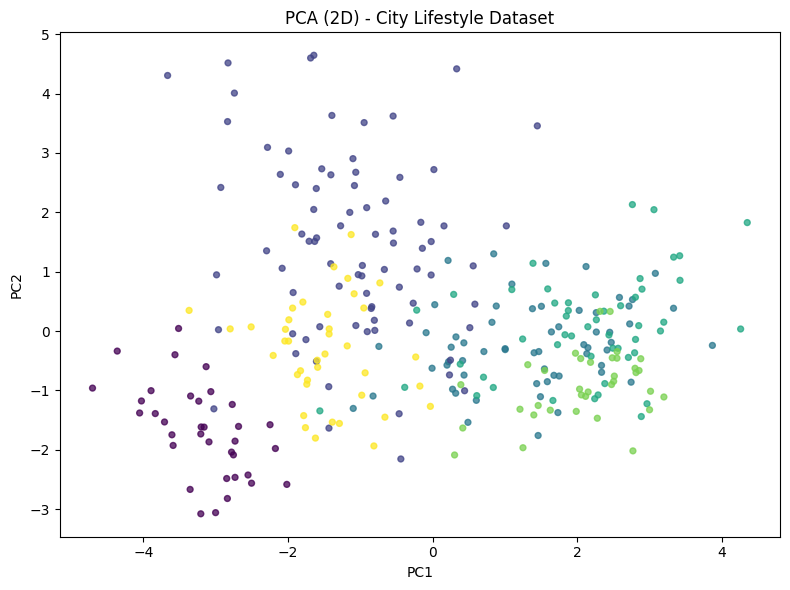

In [3]:
import matplotlib.pyplot as plt

regions = df["country"].astype("category").cat.codes

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=regions, alpha=0.75, s=18)
plt.title("PCA (2D) - City Lifestyle Dataset")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


# Observation — PCA (2D)

La projection en deux dimensions via la méthode PCA met en évidence une structuration nette des villes selon deux axes principaux.

  - La composante PC1 semble principalement représenter un axe socio-économique (revenu, loyer, digitalisation), séparant globalement les villes les plus développées des moins favorisées.

  - La composante PC2 paraît davantage associée aux dimensions environnementales et à la qualité de vie (qualité de l’air, espaces verts).

On observe des groupes relativement distincts, notamment une séparation gauche/droite marquée sur PC1, suggérant l’existence de profils urbains différenciés.

Cependant, un certain chevauchement reste visible dans la zone centrale, indiquant que certaines villes partagent des caractéristiques proches. Cela est cohérent avec le caractère linéaire de la PCA.

Globalement, la PCA conserve bien la structure globale des données, mais la séparation n’est pas parfaitement nette en deux dimensions.

In [6]:
pca_df = pd.DataFrame(X_pca, columns=["dim1", "dim2"])
pca_df["city_name"] = df["city_name"]
pca_df["country"] = df["country"]

pca_df.to_csv("outputs/pca_emb_2d.csv", index=False)
print("Fichier exporté: outputs/pca_emb_2d.csv")


Fichier exporté: outputs/pca_emb_2d.csv
